# Programming Assignment 1 — Segmentação de Instâncias

Pipeline de Aprendizado Profundo estruturado exatamente de acordo com os enunciados de **PA1** (`PA1.pdf`):
- **Parte 0**: Teste Unitário Sintético (Elipses 128x128).
- **Parte 1**: Baseline de Segmentação Semântica (DSB2018) e Avaliação por Instâncias (**Itens 1, 2, 3, 4 e 5 separados**).

In [69]:
# Setup: Auto-reload e Dispositivo
%load_ext autoreload
%autoreload 2

import os, sys, importlib, torch
sys.path.append(os.path.abspath('src'))
import utils
importlib.reload(utils)

device = utils.get_device()
print(f"Dispositivo: {device}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Dispositivo: mps


In [70]:
# Modelo: U-Net ResNet18
model_test = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True).to(device)
dummy_in = torch.randn(2, 3, 128, 128, device=device)
print(f"Modelo carregado. Output: {tuple(model_test(dummy_in).shape)}")


Modelo carregado. Output: (2, 1, 128, 128)


--- 
## Parte 0 — Teste Unitário Sintético
> **Enunciado Parte 0:** *Gerar dataset sintético de 100 imagens 128x128 com 5 a 20 elipses. Treinar em menos de 5 minutos e reportar a métrica.*

In [71]:
# Parte 0 — Dataset Sintético (100 imagens 128x128)
images_synth, masks_synth = utils.gerar_dataset_elipses(num_images=100, image_size=(128, 128), num_ellipses_range=(5, 20), seed=42)
X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s = utils.split_dataset(images_synth, masks_synth, seed=42)
print(f"Dataset Sintético | Treino: {X_tr_s.shape[0]} | Val: {X_v_s.shape[0]} | Teste: {X_te_s.shape[0]}")


Dataset Sintético | Treino: 70 | Val: 15 | Teste: 15


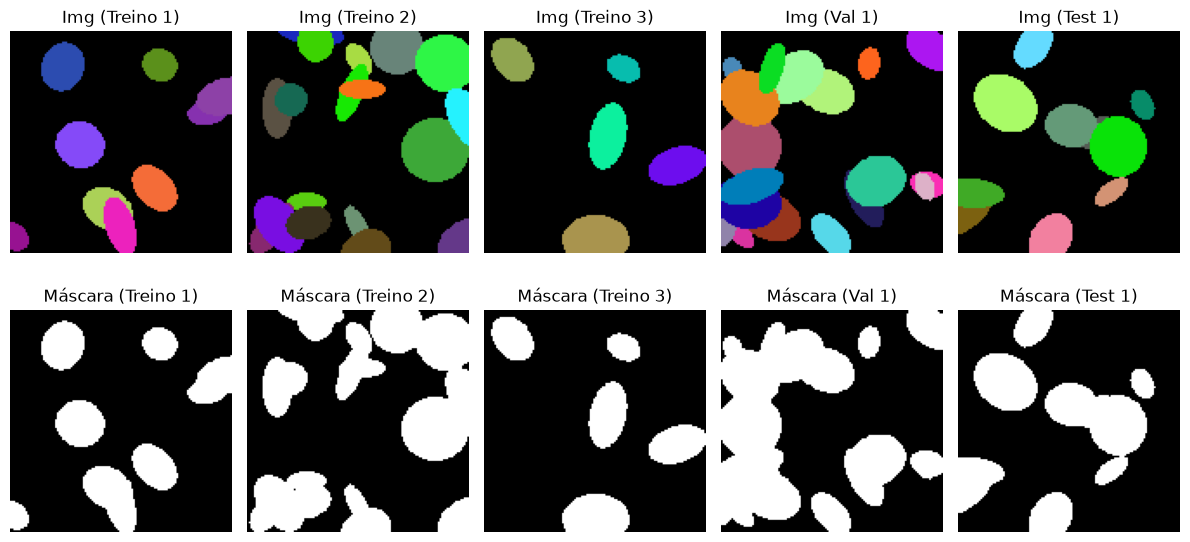

In [72]:
# Parte 0 — Visualização de Amostras Sintéticas
utils.plot_dataset_samples(X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s)


In [73]:
# Parte 0 — Treinamento Rápido U-Net (< 5 min)
model_synth = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_synth, X_tr_s, y_tr_s, X_v_s, y_v_s, device, num_epochs=10, batch_size=8)


Epoch [ 1/10] | Train Loss: 0.3501 | Val Loss: 0.5894
Epoch [ 2/10] | Train Loss: 0.2077 | Val Loss: 0.3738
Epoch [ 3/10] | Train Loss: 0.1697 | Val Loss: 0.2278
Epoch [ 4/10] | Train Loss: 0.1425 | Val Loss: 0.1614
Epoch [ 5/10] | Train Loss: 0.1214 | Val Loss: 0.1324
Epoch [ 6/10] | Train Loss: 0.1049 | Val Loss: 0.1102
Epoch [ 7/10] | Train Loss: 0.0917 | Val Loss: 0.0931
Epoch [ 8/10] | Train Loss: 0.0812 | Val Loss: 0.0807
Epoch [ 9/10] | Train Loss: 0.0727 | Val Loss: 0.0708
Epoch [10/10] | Train Loss: 0.0658 | Val Loss: 0.0631


In [74]:
# Parte 0 — Avaliação Semântica (Dice & IoU)
dice_s, iou_s = utils.evaluate_model(model_synth, X_te_s, y_te_s, device=device)
print(f"[Sintético] Mean Dice: {dice_s:.4f} | Mean IoU: {iou_s:.4f}")


[Sintético] Mean Dice: 0.9827 | Mean IoU: 0.9660


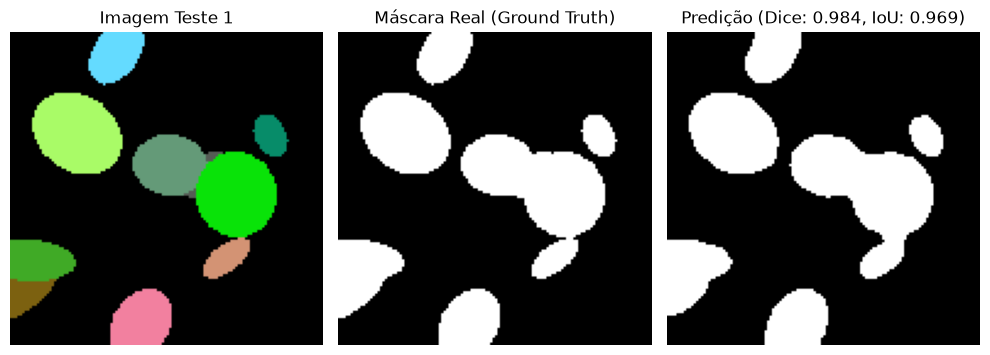

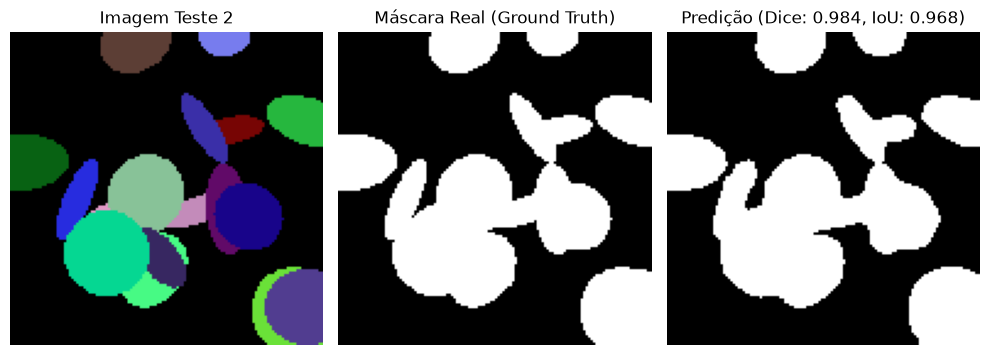

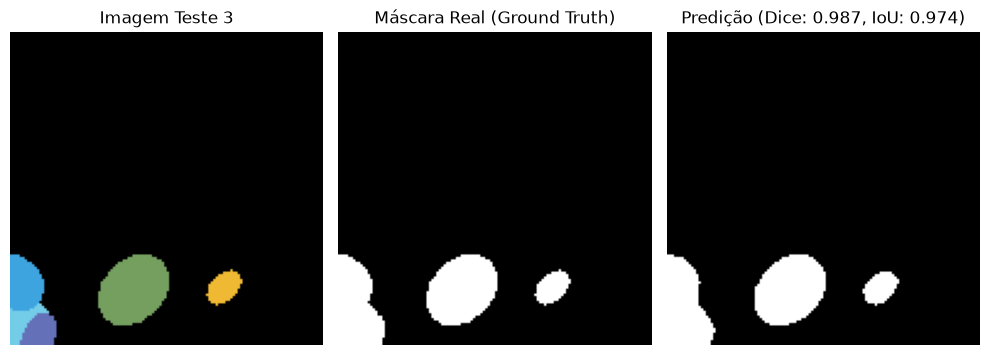

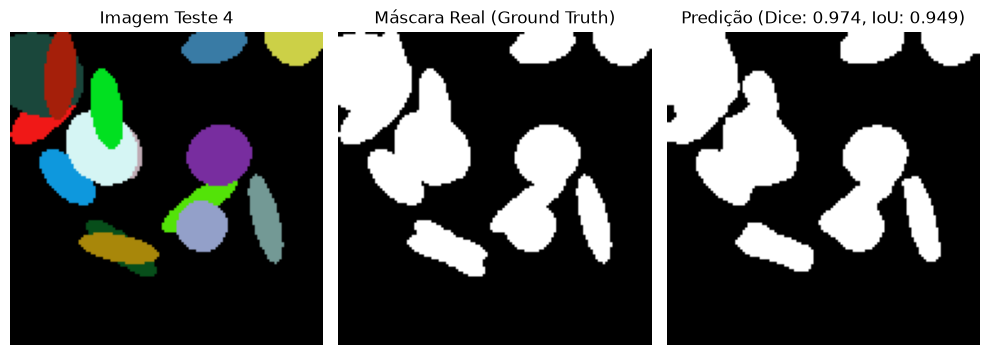

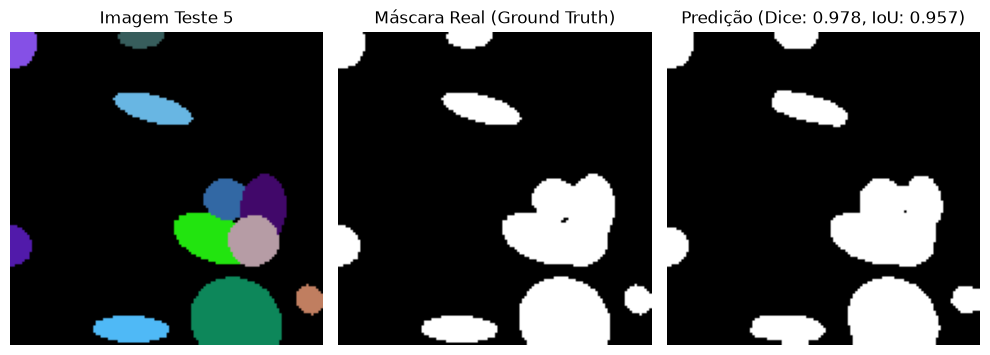

In [75]:
# Parte 0 — Visualização das Predições
utils.plot_predictions(model_synth, X_te_s, y_te_s, device=device, num_samples=5)


--- 
## Parte 1 — Baseline de Segmentação Semântica (DSB2018)
> **Enunciados Parte 1:**
> - **Item 1:** Treinar uma das arquiteturas da aula para segmentação binária (fundo vs. objeto). Reportar IoU e Dice.
> - **Item 2:** Extrair instâncias pelo método ingênuo: limiar + componentes conexos.
> - **Item 3:** Avaliar como instâncias. Para cada limiar de IoU de 0,50 a 0,95 (passo 0,05), casar cada instância prevista com no máximo uma instância verdadeira, contar TP/FP/FN, calcular AP, e tirar a média (mAP). Reportar também o erro absoluto de contagem por imagem.
> - **Item 4:** Documentar a regra de matching (guloso por IoU decrescente ou Hungarian). Regras diferentes dão números diferentes — a escolha é de vocês, mas tem que estar explícita.
> - **Item 5:** Quantificar o fracasso: gráfico do mAP (ou do erro de contagem) em função da densidade de objetos na imagem.

In [77]:
# Dados Reais — Carregamento DSB2018 (stage1_train)
stage1_path = "../data/stage1_train" if os.path.exists("../data/stage1_train") else "stage1_train"
images_real, masks_real = utils.carregar_dataset_real(stage1_path, target_size=(128, 128))
X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r = utils.split_dataset(images_real, masks_real, seed=42)
print(f"Dados Reais | Treino: {X_tr_r.shape[0]} | Val: {X_v_r.shape[0]} | Teste: {X_te_r.shape[0]}")


Carregando 670 amostras de '../data/stage1_train'...
Dataset real carregado em 10.48 segundos!
Dados Reais | Treino: 468 | Val: 101 | Teste: 101


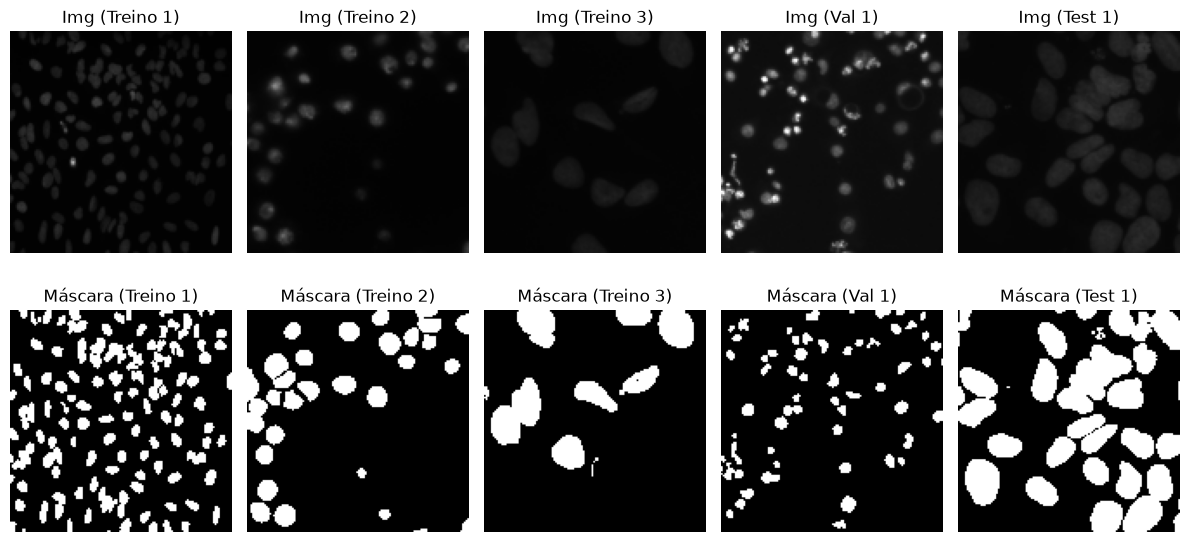

In [78]:
# Dados Reais — Visualização de Amostras
utils.plot_dataset_samples(X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r)


In [79]:
# Parte 1 (Item 1) — Treinamento e Avaliação Semântica (Dice & IoU)
model_real = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_real, X_tr_r, y_tr_r, X_v_r, y_v_r, device, num_epochs=10, batch_size=16)

dice_r, iou_r = utils.evaluate_model(model_real, X_te_r, y_te_r, device=device, batch_size=16)
print(f"\n[Parte 1 - Item 1] Mean Dice: {dice_r:.4f} | Mean IoU: {iou_r:.4f}")


Epoch [ 1/10] | Train Loss: 0.4039 | Val Loss: 0.3687
Epoch [ 2/10] | Train Loss: 0.2349 | Val Loss: 0.2129
Epoch [ 3/10] | Train Loss: 0.1765 | Val Loss: 0.1622
Epoch [ 4/10] | Train Loss: 0.1452 | Val Loss: 0.1455
Epoch [ 5/10] | Train Loss: 0.1273 | Val Loss: 0.1305
Epoch [ 6/10] | Train Loss: 0.1160 | Val Loss: 0.1187
Epoch [ 7/10] | Train Loss: 0.1084 | Val Loss: 0.1156
Epoch [ 8/10] | Train Loss: 0.1010 | Val Loss: 0.1122
Epoch [ 9/10] | Train Loss: 0.0957 | Val Loss: 0.1068
Epoch [10/10] | Train Loss: 0.0912 | Val Loss: 0.1038

[Parte 1 - Item 1] Mean Dice: 0.8273 | Mean IoU: 0.7238


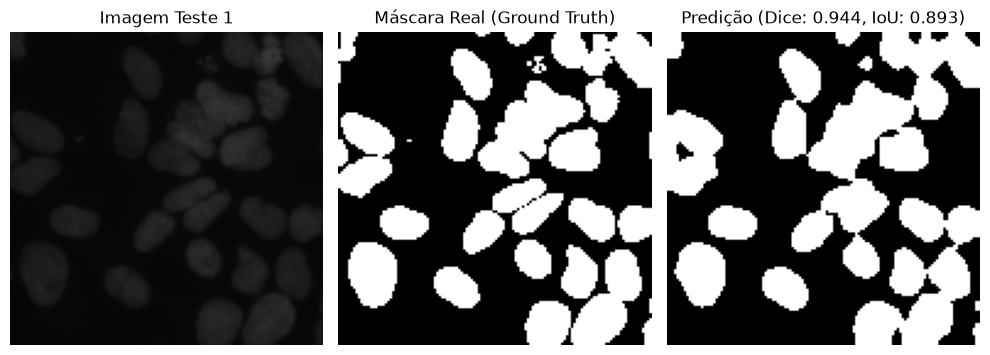

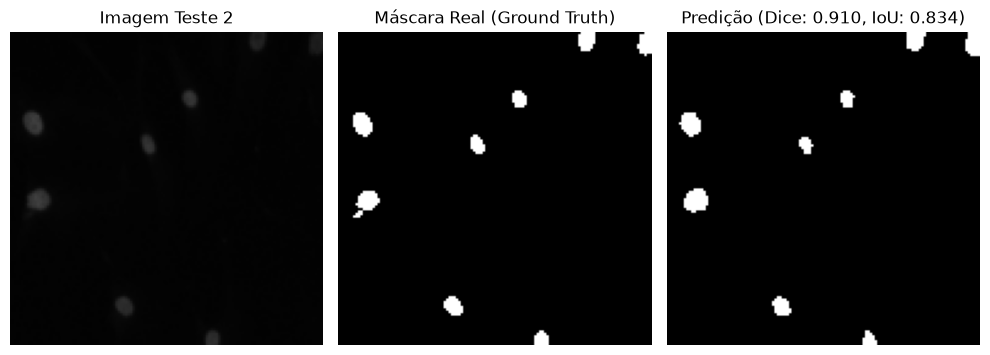

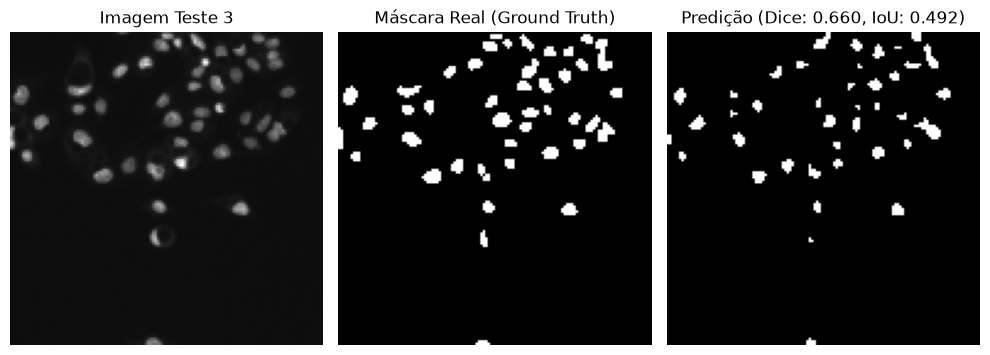

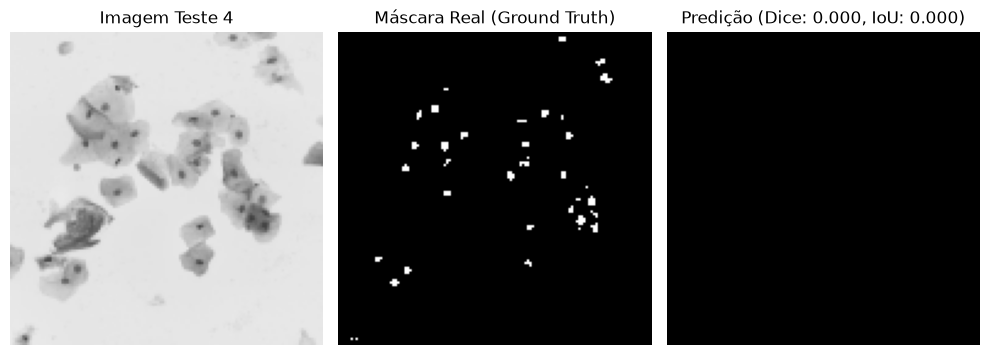

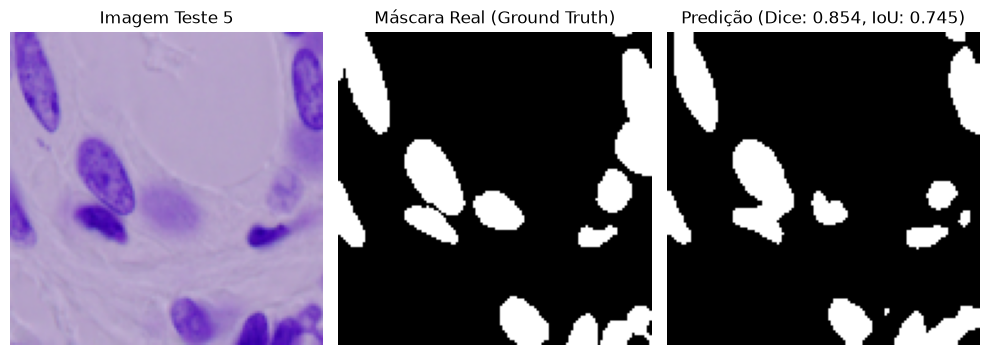

In [80]:
# Parte 1 (Item 1) — Visualização das Predições Binárias
utils.plot_predictions(model_real, X_te_r, y_te_r, device=device, num_samples=5)


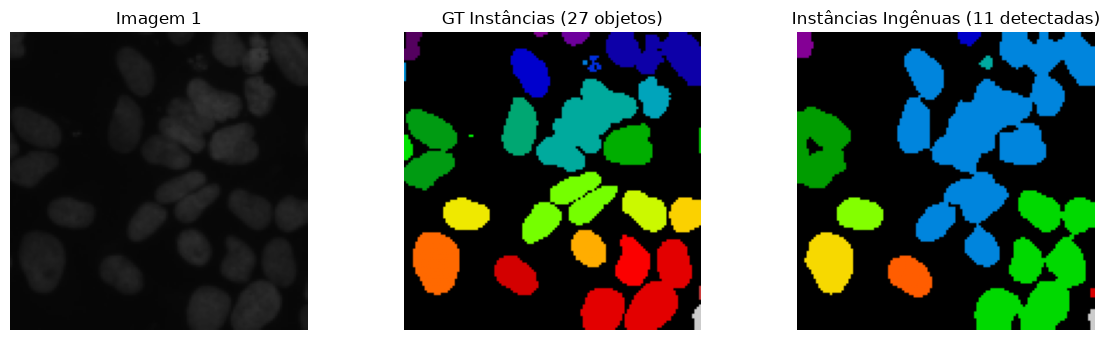

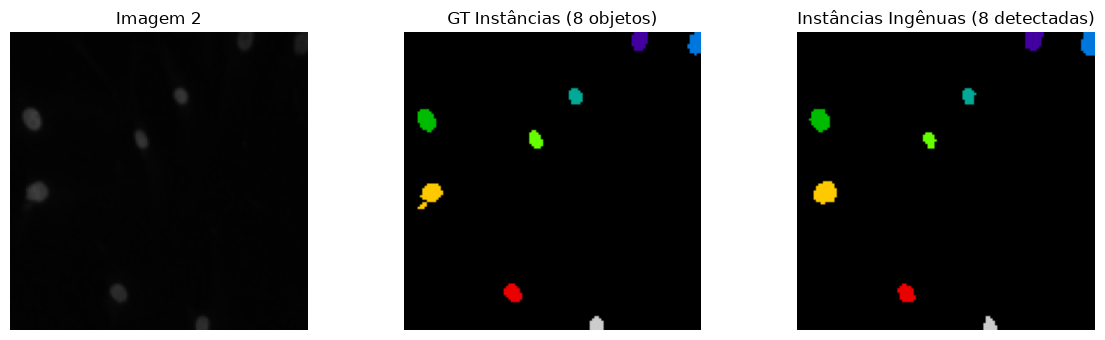

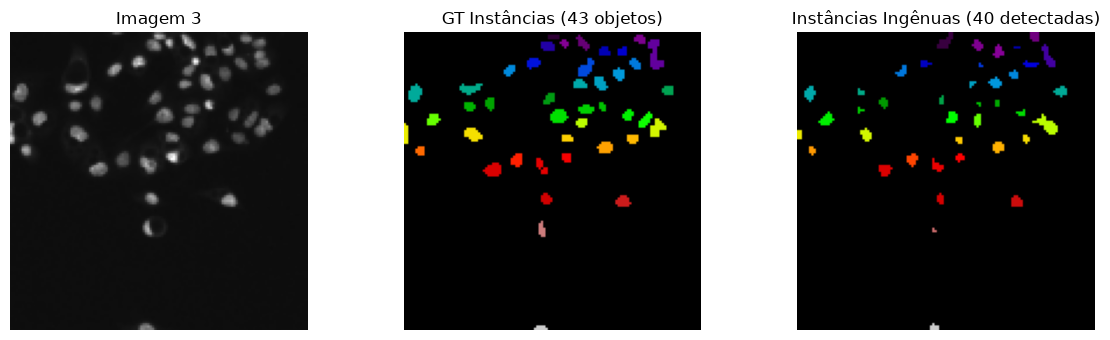

In [81]:
# Parte 1 (Item 2) — Extração Ingênua de Instâncias (Limiar + Componentes Conexos)
utils.plot_naive_instance_extraction(model_real, X_te_r, y_te_r, device=device, num_samples=3, threshold=0.5)


In [ ]:
# Parte 1 (Item 3) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95, passo 0,05), mAP@[.50:.95] e Erro Absoluto de Contagem por Imagem
res_instance_real = utils.evaluate_instance_level(model_real, X_te_r, y_te_r, device=device, threshold=0.5, matching_method="hungarian", dataset_name="Reais (DSB2018)")


--- [Item 3] Avaliação por Instâncias (Reais (DSB2018)) ---
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6209
  IoU = 0.55 : AP = 0.5676
  IoU = 0.60 : AP = 0.5200
  IoU = 0.65 : AP = 0.4665
  IoU = 0.70 : AP = 0.3996
  IoU = 0.75 : AP = 0.3292
  IoU = 0.80 : AP = 0.2652
  IoU = 0.85 : AP = 0.1696
  IoU = 0.90 : AP = 0.0852
  IoU = 0.95 : AP = 0.0113

--> mAP@[.50:.95] Final: 0.3435
--> Erro Absoluto Médio de Contagem por Imagem: 5.15 objetos


In [85]:
# Parte 1 (Item 4) — Documentação e Comparação da Regra de Matching (Guloso por IoU Decrescente vs. Algoritmo Húngaro)
res_g_real, res_h_real = utils.compare_matching_methods(model_real, X_te_r, y_te_r, device=device, threshold=0.5, dataset_name="Reais (DSB2018)")



--- [Item 4] Comparação da Regra de Matching (Reais (DSB2018)) ---
Guloso (Greedy):    mAP@[.50:.95] = 0.3435 | Erro Médio Contagem = 5.15
Húngaro (Hungarian): mAP@[.50:.95] = 0.3435 | Erro Médio Contagem = 5.15
Regra de matching documentada e explicitada: Algoritmo Húngaro (Hungarian)


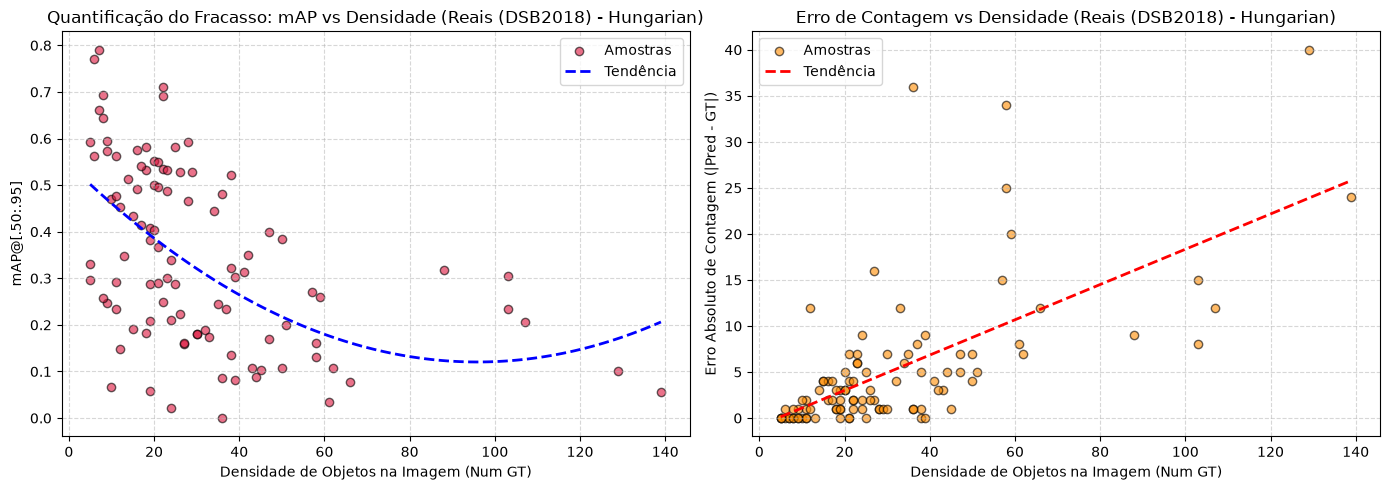

In [86]:
# Parte 1 (Item 5) — Quantificação do Fracasso: Gráficos de mAP e Erro de Contagem vs. Densidade de Objetos
utils.plot_quantify_failure(res_instance_real, dataset_name="Reais (DSB2018)")


## Relatório da Parte 1 (Itens 1 a 5)

- **Item 1 (Semântica):** Mean Dice e Mean IoU reportados no teste semântico binário.
- **Item 2 (Extração Ingênua):** Limiar $0.5$ + componentes conexos de 8-conectividade.
- **Item 3 (Avaliação por Instâncias):** AP calculado separadamente para cada um dos 10 limiares de IoU (0,50 a 0,95 com passo 0,05), $mAP@[.50:.95]$ e erro absoluto médio de contagem por imagem.
- **Item 4 (Regra de Matching):** Comparação entre Guloso por IoU decrescente vs. Algoritmo Húngaro (Munkres). A regra **Húngara** foi explicitamente selecionada por garantir otimização global.
- **Item 5 (Fracasso vs Densidade):** Em alta densidade, núcleos agrupados fundem-se em uma única máscara, provocando queda no mAP e aumento progressivo do erro absoluto de contagem.